In [2]:
import math
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline 

In [5]:
def f(x):
    return 3*x**2 - 4*x + 5

In [7]:
f(3.0) 

20.0

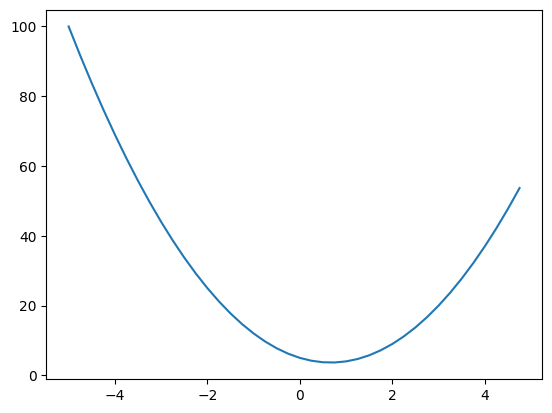

In [15]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

##### Understanding Derivatives

In [22]:
h = 0.000001
x = 2/3
(f(x+h) - f(x))/h

2.999378523327323e-06

In [23]:
# Lets get more complex
a = 2.0
b = -3.0
c = 10.0

d = a*b + c

print(d)

4.0


In [29]:
h = 0.000001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print("d1", d1, "\nd2", d2)
print("slope", (d2 - d1)/h)

d1 4.0 
d2 3.9999969999999996
slope -3.000000000419334


In [481]:
class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self._backward=lambda: None
        self.grad= 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __radd__(self, other): # for reverse addition --> other + self
        return self + other
        
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward 
        return out

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)
        
    def __rmul__(self, other): # for reverse multiplication --> other * self
        return self * other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        return out

    def __pow__(self, other): # self^other
        assert isinstance(other, (int, float)), "Only supporting int/ float powers for now"
        out = Value(self.data**other, (self, ), f"**{other}")

        def _backward():
            self.grad += other * self.data **(other - 1) * out.grad

        out._backward = _backward
        return out
        
    def __truediv__(self, other): # self / other
        return self * other**(-1)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward 
        return out

    def exp(self):
        x=self.data
        out=Value(math.exp(x), (self, ), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward=_backward
        return out

    def backward(self):
        topo = []
        visited = set()
        
        # Recursion used for getting the topology
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0 # base case
        for node in reversed(topo):
            node._backward()
        

In [368]:
# Visualise the expression and its evolution

from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad, ), shape="record")
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot
            

In [295]:
def lol():

    h = 0.0001
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    
    e = a*b; e.label = "e"
    
    d = e + c; d.label = "d"
    
    f = Value(-2.0, label="f")
    
    L = d*f; L.label = "L"
    L1 = L.data

    h = 0.0001
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    
    e = a*b; e.label = "e"
    
    d = e + c; d.label = "d"
    
    f = Value(-2.0, label="f")
    
    L = d*f; L.label = "L"
    L2 = L.data + h

    print((L2 - L1)/h)

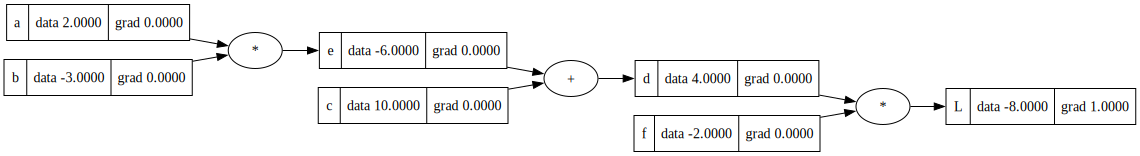

In [296]:
draw_dot(L)

In [297]:
lol()

0.9999999999976694


In [298]:
L.grad = 1

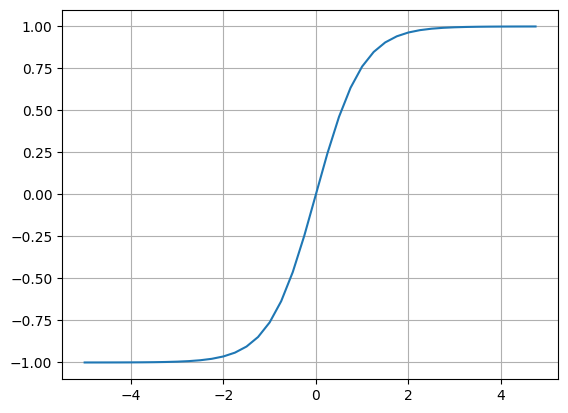

In [299]:
plt.plot(np.arange(-5,5,0.25), np.tanh(np.arange(-5,5, 0.25))); plt.grid()

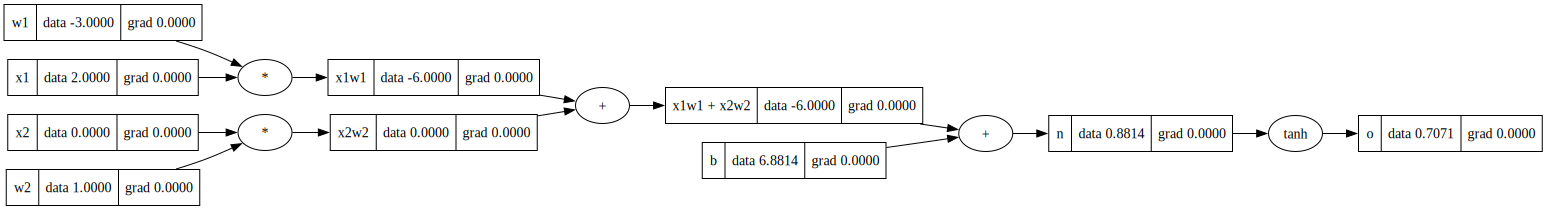

In [332]:
# input x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias for the neuron
b = Value(6.8813735, label="b")

# x1*w1 + x2*w2 + b
x1w1=x1*w1; x1w1.label="x1w1"
x2w2=x2*w2; x2w2.label="x2w2"

# x1w1 + x2w2
x1w1x2w2=x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"

# neuron
n=x1w1x2w2 + b; n.label="n" 

# o output after tanh
o=n.tanh(); o.label="o"
# draw n
draw_dot(o)

In [302]:
# Automatic backpropagation
o.grad = 1.0 # base case

o._backward()

In [303]:
n._backward()

In [304]:
b._backward()

In [305]:
x1w1x2w2._backward()

In [306]:
x2w2._backward()
x1w1._backward()

In [308]:
x1._backward()

In [177]:
o.grad=1.0 # base case

# o = tanh(n)
# do/dn = 1 - tanh(n)**2 --> 1 - o**2

n.grad = 1 - o.data**2
n.grad = 0.5

# + operation grad --> propagate the local dericative to its childern
b.grad=0.5
x1w1x2w2.grad=0.5 

# again + operator
x1w1.grad=0.5
x2w2.grad=0.5

# x1, x2, w1, w2 gradients -> slope*other.data
x1.grad=w1.data*x1w1.grad
w1.grad=x1.data*x1w1.grad

x2.grad=w2.data*x2w2.grad
w2.grad=x2.data*x2w2.grad

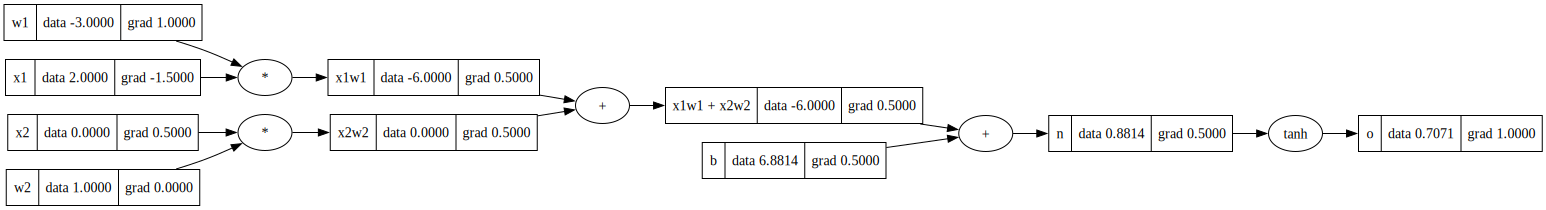

In [334]:
draw_dot(o)

In [333]:
o.backward()

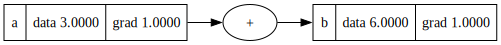

In [339]:
# Bug to be fixed

a = Value(3.0, label="a")
b = a + a; b.label = "b"
b.backward()
draw_dot(b)

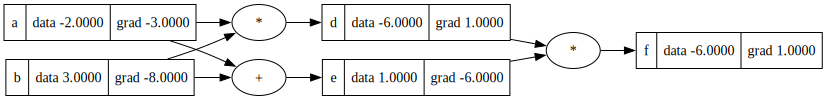

In [358]:
# More complex way to see the bug

a = Value(-2.0, label="a")
b = Value(3.0, label="b")

d = a*b; d.label="d"
e = a+b; e.label="e"
f = d*e; f.label="f"

f.backward()
draw_dot(f)

In [373]:
a = Value(2)
b = a**2
b.backward()

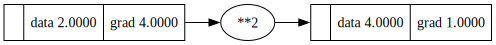

In [374]:
draw_dot(b)

In [416]:
x = Value(2, label="x")
a = 2*x; a.label="a"
b = a.exp(); b.label="b"
c = (b - 1) / (b + 1); c.label="c"
c.backward()

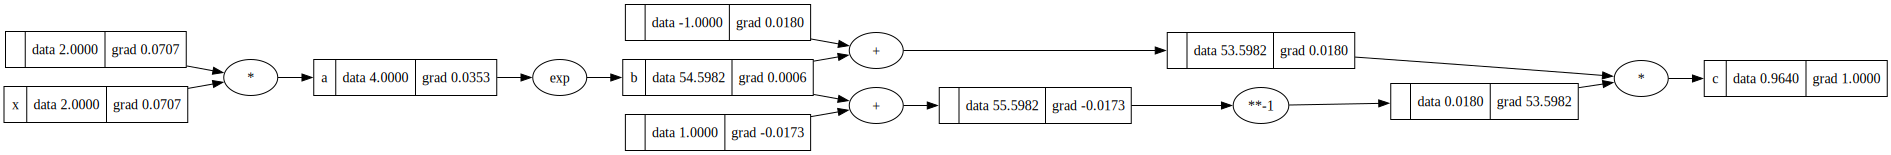

In [417]:
draw_dot(c)

In [411]:
math.tanh(2)

0.9640275800758169

#### Verifying the work with PyTorch

In [419]:
import torch

x1=torch.Tensor([2.0]).double()                   ; x1.requires_grad=True
x2=torch.Tensor([0.0]).double()                   ; x2.requires_grad=True
w1=torch.Tensor([-3.0]).double()                  ; w1.requires_grad=True
w2=torch.Tensor([1.0]).double()                   ; w2.requires_grad=True

b=torch.Tensor([6.8813735]).double()              ; w2.requires_grad=True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("==== grads ====")
print("x1", x1.grad.item())
print("x2", x2.grad.item())
print("w1", w1.grad.item())
print("w2", w2.grad.item())

0.7071066904050358
==== grads ====
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


#### Creating Neuron Class

In [493]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w . x + b --> Dot product
        act = sum((wi*xi for wi, xi in zip(self.w, x)),  self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [631]:
x = [2, 4, 6]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.2849719555205481)

In [635]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired o/p

ypred = [n(x) for x in xs]
ypred

[Value(data=0.9999999998199435),
 Value(data=-0.9998669044787646),
 Value(data=-0.9805938698766234),
 Value(data=0.999999999776099)]

In [636]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # setting grad = 0.0
    for p in n.parameters():
        p.grad = 0.0
        
    # backward pass
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k+1, loss.data)

1 0.0003766156007831959
2 0.00037158358068554786
3 0.000366688686636913
4 0.0003619253385368257
5 0.0003572882562807673
6 0.00035277243981621676
7 0.00034837315077144884
8 0.0003440858955143937
9 0.00033990640951291447
10 0.0003358306428814762
11 0.0003318547470100288
12 0.00032797506218202346
13 0.000324188106096787
14 0.0003204905632202189
15 0.0003168792748946875
16 0.00031335123014583865
17 0.000309903557129331
18 0.0003065335151663322
19 0.0003032384873208014
20 0.0003000159734760652


In [637]:
ypred

[Value(data=0.9999999998198413),
 Value(data=-0.9998703458306667),
 Value(data=-0.9826795160785722),
 Value(data=0.9999999997763159)]

In [1]:
import math
from micrograd.micrograd import Value
from micrograd.build_graph import draw_dot
from micrograd.nn import MLP

In [2]:
# input x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias for the neuron
b = Value(6.8813735, label="b")

# x1*w1 + x2*w2 + b
x1w1=x1*w1; x1w1.label="x1w1"
x2w2=x2*w2; x2w2.label="x2w2"

# x1w1 + x2w2
x1w1x2w2=x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"

# neuron
n=x1w1x2w2 + b; n.label="n" 

# o output after tanh
o=n.tanh(); o.label="o"

In [6]:
# Building NN architecture --> 3(I/P), 4(HL), 4(HL), 1(O/P)
x = [2, 4, 6]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.1785126763956268)

In [7]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired o/p

ypred = [n(x) for x in xs]
ypred

[Value(data=0.4309608294224015),
 Value(data=0.3185423040211249),
 Value(data=0.3452225290474176),
 Value(data=0.4729101340789261)]

In [8]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # setting grad = 0.0
    for p in n.parameters():
        p.grad = 0.0
        
    # backward pass
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k+1, loss.data)

1 4.149806764558404
2 3.4011506890062364
3 3.0012859352500376
4 2.40522496576566
5 1.604205248389017
6 0.9065333449089806
7 0.5500427702802262
8 0.38928001008794433
9 0.2994098382864383
10 0.2407647351329414
11 0.1998670833810383
12 0.16992962058470518
13 0.14718772400224983
14 0.1293985160380756
15 0.11514929935212104
16 0.10350959271553752
17 0.0938435633409779
18 0.08570311667304799
19 0.0787640708435561
20 0.072786531650636


In [9]:
ypred

[Value(data=0.9249760517903836),
 Value(data=-0.9284668240347331),
 Value(data=-0.8238411159931707),
 Value(data=0.8239063000347048)]